<a href="https://colab.research.google.com/github/nikhilharins1/projectportfolio/blob/main/EDA_NoShow_Harins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluacion integradora S01-S04 - Analisis Exploratorio (EDA) del No-Show

**Asignatura:** Ciencia de Datos Aplicada a Negocio - Master en Analitica de Negocios (UNIE)
**Edicion:** 2604 - **Modulos evaluados:** S01-S04 - **Caso:** No-Show (citas medicas, Vitoria, Brasil)

---

**Estudiante:** _Nikhil Harins_  -  **Fecha:** _29/05/2026_

| Entrega | Detalle |
|---|---|
| Fecha limite | **domingo 31/05/2026, 23:45h** |
| Formato | `EDA_NoShow_Harins.ipynb` (un solo archivo) |
| Plataforma | Aula Virtual |

## De que va esta actividad

No es teoria nueva: es **tu** recorrido completo por el proceso que construimos en S01-S04, aplicado de principio a fin y **defendido como negocio**. Lo que evaluamos no es que sepas las librerias, sino que sepas **conducir el proceso tu solo/a** y **justificar cada decision** con los marcos del curso: **CRISP-DM, EDA, DAMA-5, PECO y Project Canvas**.

> El dataset de esta evaluacion es un **subset de datos reales "sucios"**: contiene problemas de calidad tipicos que **no** vimos resueltos en clase. Detectarlos y decidir que hacer con ellos es parte de la nota.


## El dataset

`noshow_appointments_subset.csv` (~20.050 citas). Descargalo del Aula Virtual y dejalo junto al notebook (o en tu Drive). La celda de carga usa `data_path`, igual que en los notebooks de clase. Variables principales:

| Variable | Significado | Nota |
|---|---|---|
| `No-show` | **Yes = NO asistio**, No = si asistio | codificacion invertida |
| `ScheduledDay`, `AppointmentDay` | fecha de registro y de la cita | vienen como texto |
| `Age` | edad del paciente | revisa el rango |
| `Gender` | genero | revisa los valores unicos |
| `Neighbourhood` | barrio | revisa la consistencia de nombres |
| `Scholarship`, `Hipertension`, `Diabetes`, `Alcoholism`, `Handcap` | flags sociales/clinicos | `Handcap` es 0-4; ojo a los nombres de columna |
| `SMS_received` | recordatorio enviado | cuidado con la causalidad |
| `PatientId`, `AppointmentID` | identificadores | una fila = una **cita**, no un paciente |

## Como trabajar (1 semana)

Sugerencia de reparto: **Dia 1-2** encuadre + Data Understanding (sec. 0-1) - **Dia 3-4** preparacion + evidencia PECO (sec. 2-3) - **Dia 5-6** visualizacion (sec. 4) - **Dia 7** Canvas, decision y reflexion (sec. 5-6). No lo dejes para el ultimo dia.

## Uso de IA (regla del curso)

Puedes usar IA para escribir codigo, explicar errores y proponer enfoques. **No puedes delegar tu criterio analitico**: la pregunta, la validacion y la interpretacion son tuyas. Un buen prompt incluye contexto de negocio, los **nombres reales** de las columnas y la restriccion de *no inventar columnas, datos ni funciones*.


In [137]:
# Setup y carga de datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [138]:
RANDOM_STATE = 14                       # convencion del curso
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

In [139]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [140]:
# Carga del dataset (mismo metodo que en clase). Ajusta data_path a donde tengas el CSV.
#data_path = "noshow_appointments_subset.csv"
#df_raw = pd.read_csv(data_path)

# --- Alternativa Google Colab con Drive ---
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [141]:
#connectar el dataset cargado en drive
data_path = "/content/drive/MyDrive/Master Business Analytics/Ciencia de datos Aplicada en negocio/Jaime/Examen practicas/noshow_appointments_subset.csv"
df_raw = pd.read_csv(data_path)

In [142]:

print(f"Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
df_raw.head(3)

Dataset cargado: 20,050 filas x 14 columnas


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.683363e+14,5470230,F,2016-03-15T10:18:20Z,2016-05-02T00:00:00Z,44.0,ILHA DE SANTA MARIA,0,0,0,0,0,1,No
1,1.334426e+14,5638547,M,2016-04-29T08:08:44Z,2016-05-02T00:00:00Z,4.0,DA PENHA,0,0,0,0,0,1,Yes
2,6.325237e+14,5640236,F,2016-04-29T10:20:50Z,2016-05-24T00:00:00Z,45.0,CENTRO,0,0,0,0,0,1,No


In [143]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20050 entries, 0 to 20049
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PatientId       20050 non-null  float64
 1   AppointmentID   20050 non-null  int64  
 2   Gender          20050 non-null  object 
 3   ScheduledDay    20050 non-null  object 
 4   AppointmentDay  20050 non-null  object 
 5   Age             19650 non-null  float64
 6   Neighbourhood   19850 non-null  object 
 7   Scholarship     20050 non-null  int64  
 8   Hipertension    20050 non-null  int64  
 9   Diabetes        20050 non-null  int64  
 10  Alcoholism      20050 non-null  int64  
 11  Handcap         20050 non-null  int64  
 12  SMS_received    20050 non-null  int64  
 13  No-show         20050 non-null  object 
dtypes: float64(2), int64(7), object(5)
memory usage: 2.1+ MB


In [144]:
df_raw.count()

,0
PatientId,20050
AppointmentID,20050
Gender,20050
ScheduledDay,20050
AppointmentDay,20050
Age,19650
Neighbourhood,19850
Scholarship,20050
Hipertension,20050
Diabetes,20050


# 0.- Encuadre - CRISP-DM: Business Understanding

> **CRISP-DM: Business Understanding.** Antes de tocar datos, fija el marco. Esto debe coincidir con tu **Project Canvas** (lo consolidaras al final, en la **seccion 5 - Project Canvas**).

Anota aqui un borrador (una linea cada uno); lo consolidaras con evidencia en la **seccion 5**:

- **Problema de negocio:** Tasa de No-Show de la clinica es demasiodo alta. Para la clinica es tiempo de citas perdida que se podria dar a alguien mas.
- **KPI + baseline:** Lagging : NOSHOW
Leading : SMS_Received, waiting days (recuerda distinguir *lagging* vs *leading*; el baseline de no-show lo confirmaras en la seccion 1) Baseline : 20.2%
- **3 hipotesis PECO (H1, H2, H3):** una linea cada una con P / E / C / O.
- **Decision candidata inicial:** _que haria el hospital si la evidencia la apoya._


# 1.- Data Understanding - EDA + DAMA-5

## 1.1.- EDA: las 5 preguntas canonicas

> **EDA.** Responde con codigo **y** una lectura breve, en este orden:
> 1. **Forma:** cuantas filas y columnas, y de que tipo.
> 2. **Unidad de observacion:** que representa una fila.
> 3. **Distribucion del objetivo:** como se reparte `No-show` (confirma el baseline).
> 4. **Anomalias:** valores que no cuadran (rango de `Age`, valores unicos de `Gender`, etc.).
> 5. **Variables que faltan:** que necesitaras construir para tus hipotesis.


In [145]:
# Tu codigo - EDA inicial (shape, dtypes, head, info, distribucion de No-show, describe...)


In [146]:
# ANALYSIS EXPLORATORIO DE "SHAPE" DE DF
df_raw.shape

(20050, 14)

In [147]:
# ANALYSIS EXPLORATORIO DE "DTYPE" DE DF
df_raw.dtypes

,0
PatientId,float64
AppointmentID,int64
Gender,object
ScheduledDay,object
AppointmentDay,object
Age,float64
Neighbourhood,object
Scholarship,int64
Hipertension,int64
Diabetes,int64


In [148]:
# ANALYSIS EXPLORATORIO DE "HEAD" DE DF
df_raw.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.683363e+14,5470230,F,2016-03-15T10:18:20Z,2016-05-02T00:00:00Z,44.0,ILHA DE SANTA MARIA,0,0,0,0,0,1,No
1,1.334426e+14,5638547,M,2016-04-29T08:08:44Z,2016-05-02T00:00:00Z,4.0,DA PENHA,0,0,0,0,0,1,Yes
2,6.325237e+14,5640236,F,2016-04-29T10:20:50Z,2016-05-24T00:00:00Z,45.0,CENTRO,0,0,0,0,0,1,No
3,9.619846e+13,5602700,F,2016-04-19T15:34:47Z,2016-05-17T00:00:00Z,20.0,JESUS DE NAZARETH,0,0,0,0,0,0,No
4,5.536926e+13,5624080,F,2016-04-26T15:11:00Z,2016-05-16T00:00:00Z,23.0,JARDIM DA PENHA,0,0,0,0,0,0,No


In [149]:
# ANALYSIS EXPLORATORIO DE "INFO" DE DF
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20050 entries, 0 to 20049
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PatientId       20050 non-null  float64
 1   AppointmentID   20050 non-null  int64  
 2   Gender          20050 non-null  object 
 3   ScheduledDay    20050 non-null  object 
 4   AppointmentDay  20050 non-null  object 
 5   Age             19650 non-null  float64
 6   Neighbourhood   19850 non-null  object 
 7   Scholarship     20050 non-null  int64  
 8   Hipertension    20050 non-null  int64  
 9   Diabetes        20050 non-null  int64  
 10  Alcoholism      20050 non-null  int64  
 11  Handcap         20050 non-null  int64  
 12  SMS_received    20050 non-null  int64  
 13  No-show         20050 non-null  object 
dtypes: float64(2), int64(7), object(5)
memory usage: 2.1+ MB


In [150]:

# ANALYSIS EXPLORATORIO DE "distribucion de No-show" DE DF
citas_totales = df_raw["PatientId"].count()
print(citas_totales)

total_noshow = df_raw[df_raw["No-show"] == "Yes"]["PatientId"].count()
print(total_noshow)

tasa_de_noshow = (total_noshow / citas_totales) * 100
print(tasa_de_noshow)

20050
4053
20.214463840399002


In [151]:
# ANALYSIS EXPLORATORIO DE "distribucion de No-show" DE DF
df_raw.describe()



,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,2.005000e+04,2.005000e+04,19650.000000,20050.000000,20050.000000,20050.000000,20050.000000,20050.000000,20050.000000
mean,1.493516e+14,5.675782e+06,37.465751,0.098703,0.201197,0.073915,0.031022,0.021845,0.319102
std,2.556437e+14,7.101134e+04,23.602012,0.298271,0.400905,0.261639,0.173383,0.155443,0.466140
min,9.377953e+04,5.134220e+06,-10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.353286e+12,5.640295e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.325445e+13,5.681238e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.565427e+13,5.726121e+06,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.997437e+14,5.790484e+06,250.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


## 1.2.- DAMA-5: nombra cada hallazgo y su impacto

> **DAMA-5.** Este subset son **datos reales sucios**. Un hallazgo de calidad no es "algo raro": **nombralo** con su dimension y conectalo con su **impacto analitico**. Revisa al menos:
>
> - **Completitud:** hay nulos? donde y cuantos?
> - **Validez:** valores imposibles o fuera de dominio? (rango de `Age`, fechas como texto)
> - **Consistencia:** categorias mal escritas? (espacios o mayus/minus en `Gender` y `Neighbourhood`, nombres de columna con typo, `No-show` invertido)
> - **Unicidad / grano:** filas duplicadas? una fila es una cita o un paciente?


In [ ]:
# Tu codigo - chequeos DAMA-5 (isna, duplicated, value_counts, describe, nunique...)

In [152]:
#nullos

df_raw.isna().sum()

#600 Nulos

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,400
Neighbourhood,200
Scholarship,0
Hipertension,0
Diabetes,0


In [153]:
#valores duplicados

display(df_raw[["AppointmentID", "PatientId"]]
.nunique()
.to_frame(name="unique_values"))

# 50 filas duplicados

,unique_values
AppointmentID,20000
PatientId,17071


In [154]:
# cuenta de valores en cada columna

# Select columns where value_counts would be meaningful
# Exclude unique identifiers and high cardinality columns like dates
columns_for_value_counts = ['Gender', 'Neighbourhood', 'Scholarship', 'Hipertension',
                            'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']

print("Value counts for selected columns:")
for col in columns_for_value_counts:
    print(f"\n--- {col} ---")
    print(df_raw[col].value_counts())
    print("-" * (len(col) + 8)) # Separator

Value counts for selected columns:

--- Gender ---
Gender
F     12945
M      7005
F        33
 F       32
 M       18
M        17
Name: count, dtype: int64
--------------

--- Neighbourhood ---
Neighbourhood
JARDIM CAMBURI       1400
MARIA ORTIZ          1034
RESISTÊNCIA           753
JARDIM DA PENHA       696
ITARARÉ               621
                     ... 
morada de camburi       1
monte belo              1
do cabral               1
santa tereza            1
bela vista              1
Name: count, Length: 132, dtype: int64
---------------------

--- Scholarship ---
Scholarship
0    18071
1     1979
Name: count, dtype: int64
-------------------

--- Hipertension ---
Hipertension
0    16016
1     4034
Name: count, dtype: int64
--------------------

--- Diabetes ---
Diabetes
0    18568
1     1482
Name: count, dtype: int64
----------------

--- Alcoholism ---
Alcoholism
0    19428
1      622
Name: count, dtype: int64
------------------

--- Handcap ---
Handcap
0    19639
1      385
2  

In [155]:
#Utilizando describre para buscar anomalias en los valores en el dataset

df_raw.describe()

#Age tiene dtype float (lo cual no se se suele usar y puede confundir), Age tiene valores negativos y esto es imposible, hipertension y handcap estan mal escritos, hay alguien con edad mas que 100 lo cual tambien es una anomalia

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,2.005000e+04,2.005000e+04,19650.000000,20050.000000,20050.000000,20050.000000,20050.000000,20050.000000,20050.000000
mean,1.493516e+14,5.675782e+06,37.465751,0.098703,0.201197,0.073915,0.031022,0.021845,0.319102
std,2.556437e+14,7.101134e+04,23.602012,0.298271,0.400905,0.261639,0.173383,0.155443,0.466140
min,9.377953e+04,5.134220e+06,-10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.353286e+12,5.640295e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.325445e+13,5.681238e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.565427e+13,5.726121e+06,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.997437e+14,5.790484e+06,250.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


**Anota tus hallazgos** (doble clic en la celda y escribe tras cada `:`). Para cada dimension, di el hallazgo con su cifra y su impacto analitico:

- **Completitud:*600 Nulos encontrados*
- **Validez:*Age tiene dtype float (lo cual no se se suele usar y puede confundir), Age tiene valores negativos y esto es imposible, hipertension y handcap estan mal escritos, hay alguien con edad mas que 100 lo cual tambien es una anomalia, dtype de scheduled date y appointment date es object y se deberia cambiar dtype, estandardizar columnas gender y neighbournhood para eliminar espacios innecesarios y letras en mayusculas y minisculas inconsistentes, eliminar la fila con valor imposible -1  de waiting day encontrado despues de normalizar la columnas*
- **Consistencia:*En este caso la columna no show tiene un falso negativo que es una consitencia y puede affectar nuestra hipotesis final*
- **Unicidad / grano:*hay 50 filas duplicados*

Estos riesgos van a la **seccion 5 (Canvas, casilla 4)**.

# 2.- Data Preparation - CRISP-DM: Data Preparation

## 2.1.- Limpieza con decisiones justificadas

> **CRISP-DM: Data Preparation.** Construye lo que **cambia** los datos (no lo que solo los mira). Para cada problema de la seccion 1.2, **decide y justifica** (no hay una unica respuesta correcta):
>
> - Nulos: eliminar si son pocos (<5% de filas) o imputar con logica de negocio; di por que.
> - Duplicados, espacios en categorias, barrios inconsistentes, edades imposibles, fechas como texto.
> - Variable objetivo legible: `NoShow` (1 = no asistio).
>
> **Valida** cuantas filas tenias y cuantas quedan, y por que.


In [156]:
# Tu codigo - limpieza -> df_clean (trabaja sobre una copia: df_clean = df_raw.copy())
df_clean = df_raw.copy()

In [157]:
#total de nulos
df_clean.isna().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,400
Neighbourhood,200
Scholarship,0
Hipertension,0
Diabetes,0


In [158]:
#calcular porcentage de total de  nulos y  eliminar nulos sin es > 5%

porcentage_nulos = (600 / citas_totales) * 100
print(f"Porcentaje de nulos: {porcentage_nulos:.2f}%")

Porcentaje de nulos: 2.99%


In [159]:
#eliminar nulos
df_clean.dropna(inplace=True)

In [160]:
df_clean.isna().sum()
#nulos eliminado

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [161]:
# Cambiando dtype de 'Age' de float a int
df_clean['Age'] = df_clean['Age'].astype(int)

In [162]:
df_clean.dtypes

,0
PatientId,float64
AppointmentID,int64
Gender,object
ScheduledDay,object
AppointmentDay,object
Age,int64
Neighbourhood,object
Scholarship,int64
Hipertension,int64
Diabetes,int64


In [163]:
df_clean['Age'].value_counts()

,count
Age,
0,604
1,380
50,321
52,313
53,311
...,...
150,2
100,1
-2,1


In [164]:
# buscando valores imposibles en 'Age' (negativos o mayores de 100) y contando esas filas
valores_impossibles = df_clean.loc[(df_clean["Age"] < 0) | (df_clean["Age"] > 100)]
print(f"Number of impossible age values (negative or > 100): {len(impossible_age_values)}")
# Display the rows with impossible age values for review
impossible_age_values

Number of impossible age values (negative or > 100): 22


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
1018,4.458859e+12,5730028,F,2016-05-24T08:03:57Z,2016-05-24T00:00:00Z,200,JARDIM DA PENHA,0,0,0,0,0,0,No
1703,3.929747e+13,5649556,F,2016-05-03T07:03:35Z,2016-05-05T00:00:00Z,200,MARIA ORTIZ,0,0,0,0,0,0,No
2960,4.784665e+12,5652616,M,2016-05-03T10:22:21Z,2016-05-05T00:00:00Z,250,SANTO ANTÔNIO,0,0,0,0,0,0,Yes
3068,9.133572e+11,5739111,M,2016-05-25T12:42:10Z,2016-06-07T00:00:00Z,-5,JABOUR,0,0,0,0,0,1,Yes
3484,4.267660e+13,5630248,F,2016-04-27T15:02:15Z,2016-05-06T00:00:00Z,200,NOVA PALESTINA,0,0,0,0,0,1,No
6362,3.595345e+10,5604244,F,2016-04-20T07:48:03Z,2016-05-18T00:00:00Z,-2,SANTA MARTHA,0,0,0,0,0,0,No
6458,6.414363e+12,5697382,M,2016-05-13T15:41:49Z,2016-05-20T00:00:00Z,150,DA PENHA,0,0,0,0,0,0,No
8869,7.482346e+14,5717451,F,2016-05-19T07:57:56Z,2016-06-03T00:00:00Z,115,SÃO JOSÉ,0,1,0,0,0,1,No
9376,3.219271e+12,5756994,F,2016-06-01T08:51:58Z,2016-06-01T00:00:00Z,200,SANTA CLARA,0,0,0,0,0,0,No
10478,6.591950e+14,5639233,F,2016-04-29T08:49:41Z,2016-05-03T00:00:00Z,200,MARIA ORTIZ,0,0,0,0,0,1,Yes


In [165]:
#Eliminar los valores impossibles
# Los 'valores_impossibles' ya fueron identificados en la celda anterior.
# Para eliminarlos de df_clean, usamos sus índices.
indices_to_drop = valores_impossibles.index
df_clean.drop(indices_to_drop, inplace=True)
print(f"Number of rows after removing impossible age values: {len(df_clean)}")

#Hemos eliminado 600 filas con valores nulos y hemos eliminado 22 filas con valores imposibles

Number of rows after removing impossible age values: 19428


In [166]:
#cambiar dtype de scheduled day y appointment day a dtype datetime
df_clean["ScheduledDay"] = pd.to_datetime(df_clean["ScheduledDay"])
df_clean["AppointmentDay"] = pd.to_datetime(df_clean["AppointmentDay"])
df_clean.dtypes

,0
PatientId,float64
AppointmentID,int64
Gender,object
ScheduledDay,"datetime64[ns, UTC]"
AppointmentDay,"datetime64[ns, UTC]"
Age,int64
Neighbourhood,object
Scholarship,int64
Hipertension,int64
Diabetes,int64


In [167]:
#cambiar nombre de columnas hipertension y handcap a hypertension y handicap
df_clean.rename(columns={"Hipertension": "Hypertension", "Handcap": "Handicap"}, inplace=True)
df_clean.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No-show'],
      dtype='object')

In [168]:
#anadir columna de noshow con valor numerico 1 - no asistio,  si asistio
df_clean["NoShow"] = df_clean["No-show"].map({"Yes": 1, "No": 0})
df_clean.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,NoShow
0,2.683363e+14,5470230,F,2016-03-15 10:18:20+00:00,2016-05-02 00:00:00+00:00,44,ILHA DE SANTA MARIA,0,0,0,0,0,1,No,0
1,1.334426e+14,5638547,M,2016-04-29 08:08:44+00:00,2016-05-02 00:00:00+00:00,4,DA PENHA,0,0,0,0,0,1,Yes,1
2,6.325237e+14,5640236,F,2016-04-29 10:20:50+00:00,2016-05-24 00:00:00+00:00,45,CENTRO,0,0,0,0,0,1,No,0
3,9.619846e+13,5602700,F,2016-04-19 15:34:47+00:00,2016-05-17 00:00:00+00:00,20,JESUS DE NAZARETH,0,0,0,0,0,0,No,0
4,5.536926e+13,5624080,F,2016-04-26 15:11:00+00:00,2016-05-16 00:00:00+00:00,23,JARDIM DA PENHA,0,0,0,0,0,0,No,0


## 2.2.- Variables derivadas con sentido de negocio

> **EDA: variables que faltan.** Crea las que necesiten tus hipotesis. Puedes reutilizar las de clase o justificar otras:
>
> - `WaitingDays` (dias entre registro y cita) y `AppointmentWeekday`.
> - Tramos con logica de negocio: `AgeGroup`, `WaitingBin`, indicador de espera larga, indicador de barrio de riesgo, condicion cronica, etc.


In [169]:
# Tu codigo - variables derivadas

In [170]:
#derivar variable de WaitingDays
df_clean["WaitingDays"] = (df_clean["AppointmentDay"] - df_clean["ScheduledDay"]).dt.days
df_clean.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,NoShow,WaitingDays
0,2.683363e+14,5470230,F,2016-03-15 10:18:20+00:00,2016-05-02 00:00:00+00:00,44,ILHA DE SANTA MARIA,0,0,0,0,0,1,No,0,47
1,1.334426e+14,5638547,M,2016-04-29 08:08:44+00:00,2016-05-02 00:00:00+00:00,4,DA PENHA,0,0,0,0,0,1,Yes,1,2
2,6.325237e+14,5640236,F,2016-04-29 10:20:50+00:00,2016-05-24 00:00:00+00:00,45,CENTRO,0,0,0,0,0,1,No,0,24
3,9.619846e+13,5602700,F,2016-04-19 15:34:47+00:00,2016-05-17 00:00:00+00:00,20,JESUS DE NAZARETH,0,0,0,0,0,0,No,0,27
4,5.536926e+13,5624080,F,2016-04-26 15:11:00+00:00,2016-05-16 00:00:00+00:00,23,JARDIM DA PENHA,0,0,0,0,0,0,No,0,19


In [171]:
#mirar si existe algun valor imposible en la columna waiting days
df_clean["WaitingDays"].value_counts()

,count
WaitingDays,
-1,6648
1,1249
3,939
0,923
6,884
...,...
81,1
141,1
92,1


In [172]:
#para poder contar los dias entre scheduled days and appointment day deberiamos normalizar para que no aparezca -1 para citas que citaron ese mismo dia utilizando la funcion normalise para esas dos columnas
df_clean["ScheduledDay"] = pd.to_datetime(df_clean["ScheduledDay"]).dt.normalize()
df_clean["AppointmentDay"] = pd.to_datetime(df_clean["AppointmentDay"]).dt.normalize()
df_clean["WaitingDays"] = (df_clean["AppointmentDay"] - df_clean["ScheduledDay"]).dt.days
df_clean.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,NoShow,WaitingDays
0,2.683363e+14,5470230,F,2016-03-15 00:00:00+00:00,2016-05-02 00:00:00+00:00,44,ILHA DE SANTA MARIA,0,0,0,0,0,1,No,0,48
1,1.334426e+14,5638547,M,2016-04-29 00:00:00+00:00,2016-05-02 00:00:00+00:00,4,DA PENHA,0,0,0,0,0,1,Yes,1,3
2,6.325237e+14,5640236,F,2016-04-29 00:00:00+00:00,2016-05-24 00:00:00+00:00,45,CENTRO,0,0,0,0,0,1,No,0,25
3,9.619846e+13,5602700,F,2016-04-19 00:00:00+00:00,2016-05-17 00:00:00+00:00,20,JESUS DE NAZARETH,0,0,0,0,0,0,No,0,28
4,5.536926e+13,5624080,F,2016-04-26 00:00:00+00:00,2016-05-16 00:00:00+00:00,23,JARDIM DA PENHA,0,0,0,0,0,0,No,0,20


In [173]:
#mirar si existe algun valor imposible en la columna waiting days
df_clean["WaitingDays"].value_counts()

,count
WaitingDays,
0,6648
2,1249
4,939
1,923
7,884
...,...
82,1
142,1
93,1


In [174]:
#hacemos otra columna llamado AppointmentWeekday para indicar el dia de la semana que era la cita
df_clean["AppointmentWeekday"] = df_clean["AppointmentDay"].dt.day_name()
df_clean.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,NoShow,WaitingDays,AppointmentWeekday
0,2.683363e+14,5470230,F,2016-03-15 00:00:00+00:00,2016-05-02 00:00:00+00:00,44,ILHA DE SANTA MARIA,0,0,0,0,0,1,No,0,48,Monday
1,1.334426e+14,5638547,M,2016-04-29 00:00:00+00:00,2016-05-02 00:00:00+00:00,4,DA PENHA,0,0,0,0,0,1,Yes,1,3,Monday
2,6.325237e+14,5640236,F,2016-04-29 00:00:00+00:00,2016-05-24 00:00:00+00:00,45,CENTRO,0,0,0,0,0,1,No,0,25,Tuesday
3,9.619846e+13,5602700,F,2016-04-19 00:00:00+00:00,2016-05-17 00:00:00+00:00,20,JESUS DE NAZARETH,0,0,0,0,0,0,No,0,28,Tuesday
4,5.536926e+13,5624080,F,2016-04-26 00:00:00+00:00,2016-05-16 00:00:00+00:00,23,JARDIM DA PENHA,0,0,0,0,0,0,No,0,20,Monday


In [175]:
#creamos dos columnas mas llamado AgeGroup y WaitingBin AgeGroup indicando a que grupo de edad partanece entre "ninez", "adolescencia", "joven", "adulto", "senior" respectivamente con estos grupos de edades bins : -1, 12, 17, 35, 64, 200 y WaitingDays ["0-3", "4-7", "8-14", "15-30", "30+"], con estos bins -1, 3, 7, 14, 30, 10_000

# Crear la columna AgeGroup
age_bins = [-1, 12, 17, 35, 64, 200]
age_labels = ["ninez", "adolescencia", "joven", "adulto", "senior"]
df_clean["AgeGroup"] = pd.cut(df_clean["Age"], bins=age_bins, labels=age_labels, right=True)

# Crear la columna WaitingBin
waiting_bins = [-1, 3, 7, 14, 30, 10_000]
waiting_labels = ["0-3", "4-7", "8-14", "15-30", "30+"]
df_clean["WaitingBin"] = pd.cut(df_clean["WaitingDays"], bins=waiting_bins, labels=waiting_labels, right=True)

df_clean.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,NoShow,WaitingDays,AppointmentWeekday,AgeGroup,WaitingBin
0,2.683363e+14,5470230,F,2016-03-15 00:00:00+00:00,2016-05-02 00:00:00+00:00,44,ILHA DE SANTA MARIA,0,0,0,0,0,1,No,0,48,Monday,adulto,30+
1,1.334426e+14,5638547,M,2016-04-29 00:00:00+00:00,2016-05-02 00:00:00+00:00,4,DA PENHA,0,0,0,0,0,1,Yes,1,3,Monday,ninez,0-3
2,6.325237e+14,5640236,F,2016-04-29 00:00:00+00:00,2016-05-24 00:00:00+00:00,45,CENTRO,0,0,0,0,0,1,No,0,25,Tuesday,adulto,15-30
3,9.619846e+13,5602700,F,2016-04-19 00:00:00+00:00,2016-05-17 00:00:00+00:00,20,JESUS DE NAZARETH,0,0,0,0,0,0,No,0,28,Tuesday,joven,15-30
4,5.536926e+13,5624080,F,2016-04-26 00:00:00+00:00,2016-05-16 00:00:00+00:00,23,JARDIM DA PENHA,0,0,0,0,0,0,No,0,20,Monday,joven,15-30


### Limpieza de columnas 'Gender' y 'Neighbourhood'

La columna 'Gender' mostró inconsistencias en el uso de mayúsculas/minúsculas y espacios (e.g., 'F', ' M', 'F '). La columna 'Neighbourhood' puede tener problemas similares. Se estandarizarán estas columnas a mayúsculas y se eliminarán espacios en blanco para asegurar consistencia.


In [176]:
# Estandarizar la columna 'Gender': eliminar espacios y convertir a mayúsculas
df_clean['Gender'] = df_clean['Gender'].str.strip().str.upper()
print("Value counts for Gender after cleaning:")
print(df_clean['Gender'].value_counts())

# Estandarizar la columna 'Neighbourhood': eliminar espacios y convertir a mayúsculas
df_clean['Neighbourhood'] = df_clean['Neighbourhood'].str.strip().str.upper()
print("\nValue counts for Neighbourhood after cleaning (top 10):")
print(df_clean['Neighbourhood'].value_counts().head(10))
print(f"Number of unique neighborhoods after cleaning: {df_clean['Neighbourhood'].nunique()}")

# Revisar la columna 'No-show' por si hay espacios o inconsistencias de capitalización
df_clean['No-show'] = df_clean['No-show'].str.strip().str.upper()
print("\nValue counts for No-show after cleaning:")
print(df_clean['No-show'].value_counts())

Value counts for Gender after cleaning:
Gender
F    12606
M     6822
Name: count, dtype: int64

Value counts for Neighbourhood after cleaning (top 10):
Neighbourhood
JARDIM CAMBURI       1390
MARIA ORTIZ          1017
RESISTÊNCIA           732
JARDIM DA PENHA       680
ITARARÉ               616
SANTA MARTHA          576
CENTRO                561
TABUAZEIRO            547
JESUS DE NAZARETH     490
SANTO ANTÔNIO         475
Name: count, dtype: int64
Number of unique neighborhoods after cleaning: 81

Value counts for No-show after cleaning:
No-show
NO     15499
YES     3929
Name: count, dtype: int64


In [177]:
df_clean.shape

(19428, 19)

In [178]:
df_clean.describe()

,PatientId,AppointmentID,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,NoShow,WaitingDays
count,1.942800e+04,1.942800e+04,19428.000000,19428.000000,19428.000000,19428.000000,19428.000000,19428.000000,19428.000000,19428.000000,19428.000000
mean,1.495269e+14,5.675716e+06,37.388151,0.099187,0.200793,0.074068,0.031192,0.022236,0.319693,0.202234,10.184167
std,2.558084e+14,7.101921e+04,23.177180,0.298920,0.400604,0.261889,0.173841,0.156596,0.466370,0.401676,15.170059
min,9.377953e+04,5.134220e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,4.354860e+12,5.640273e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.326985e+13,5.681160e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,9.573249e+13,5.725988e+06,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,15.000000
max,9.997437e+14,5.790484e+06,100.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,179.000000


In [179]:
#por algun motivo habia un valor imposible que siguio existiendo despues de normalizar las columnas scheduled day y appointment day
print(f"Number of appointments with WaitingDays = -1: {df_clean[df_clean['WaitingDays'] == -1].shape[0]}")

Number of appointments with WaitingDays = -1: 1


In [180]:
#quitamos esta fila con valor imposible para tener un dataset completamente limpio
df_clean = df_clean[df_clean['WaitingDays'] >= 0]
print(f"Number of rows after removing negative WaitingDays: {df_clean.shape[0]}")

Number of rows after removing negative WaitingDays: 19427


In [181]:
#porcentaje de tasa de no show una vez hemos limpiado y preparado todos las variables necesario
citas_totales_limpias = df_clean.shape[0]
total_noshow = df_clean[df_clean["NoShow"] == 1]["PatientId"].count()
print(f"Total de citas con No-Show (1): {total_noshow}")

tasa_de_noshow = (total_noshow / citas_totales_limpias) * 100
print(f"Tasa de No-Show: {tasa_de_noshow:.2f}%")

Total de citas con No-Show (1): 3928
Tasa de No-Show: 20.22%


In [182]:
print(citas_totales_limpias)

19427


In [183]:
print(total_noshow)
print(tasa_de_noshow)

3928
20.219282441962218


In [184]:
print(f"Dataset limpio: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas")
df_clean.head(3)

Dataset limpio: 19,427 filas x 19 columnas


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,NoShow,WaitingDays,AppointmentWeekday,AgeGroup,WaitingBin
0,2.683363e+14,5470230,F,2016-03-15 00:00:00+00:00,2016-05-02 00:00:00+00:00,44,ILHA DE SANTA MARIA,0,0,0,0,0,1,NO,0,48,Monday,adulto,30+
1,1.334426e+14,5638547,M,2016-04-29 00:00:00+00:00,2016-05-02 00:00:00+00:00,4,DA PENHA,0,0,0,0,0,1,YES,1,3,Monday,ninez,0-3
2,6.325237e+14,5640236,F,2016-04-29 00:00:00+00:00,2016-05-24 00:00:00+00:00,45,CENTRO,0,0,0,0,0,1,NO,0,25,Tuesday,adulto,15-30


**Verifica** la forma final y que no quedan nulos en las variables clave. Lleva esto a la **seccion 5 (Canvas, casilla 3)**: filas brutas/validas, variables creadas y como se regenera el dataset preparado.


# 3.- Evidencia por hipotesis - PECO

> **PECO.** Cada hipotesis se define como **P** (sobre quien) - **E** (grupo/factor observado) - **C** (contra quien comparo) - **O** (efecto sobre `NoShow`). Para cada una:
> - Calcula la tasa con `groupby` mostrando **`mean` y `count` juntos** (tasa + denominador).
> - Cierra con una **lectura** que controle **denominador** (una tasa alta con pocas citas no es una decision) y **causalidad** (asociacion != causa; p.ej. el SMS puede estar sesgado por a quien se le envia).


In [185]:
# Tasa de No-Show por SMS_received
print("\n--- No-Show Rate by SMS_received ---")
resumen_sms = df_clean.groupby("SMS_received")["NoShow"].agg(["mean", "count"])
print(resumen_sms.sort_values(by="mean", ascending=False))

# Tasa de No-Show por WaitingBin
print("\n--- No-Show Rate by WaitingBin ---")
resumen_waiting = df_clean.groupby("WaitingBin")["NoShow"].agg(["mean", "count"])
print(resumen_waiting.sort_values(by="mean", ascending=False))

# Tasa de No-Show por AgeGroup
print("\n--- No-Show Rate by AgeGroup ---")
resumen_age = df_clean.groupby("AgeGroup")["NoShow"].agg(["mean", "count"])
print(resumen_age.sort_values(by="mean", ascending=False))

# Tasa de No-Show por Neighbourhood
print("\n--- No-Show Rate by Neighbourhood (Top 10 highest No-Show) ---")
resumen_neighbourhood = df_clean.groupby("Neighbourhood")["NoShow"].agg(["mean", "count"])
print(resumen_neighbourhood.sort_values(by="mean", ascending=False).head(10))

print("\n--- No-Show Rate by Neighbourhood (Top 10 lowest No-Show) ---")
print(resumen_neighbourhood.sort_values(by="mean", ascending=True).head(10))


--- No-Show Rate by SMS_received ---
                  mean  count
SMS_received                 
1             0.276123   6211
0             0.167449  13216

--- No-Show Rate by WaitingBin ---
                mean  count
WaitingBin                 
15-30       0.335836   3064
30+         0.335373   1798
8-14        0.295044   2159
4-7         0.234445   3118
0-3         0.099914   9288

--- No-Show Rate by AgeGroup ---
                  mean  count
AgeGroup                     
adolescencia  0.273619   1122
joven         0.251574   4448
ninez         0.205656   3642
adulto        0.181495   7598
senior        0.142912   2617

--- No-Show Rate by Neighbourhood (Top 10 highest No-Show) ---
                                 mean  count
Neighbourhood                               
AEROPORTO                    1.000000      1
ILHAS OCEÂNICAS DE TRINDADE  1.000000      2
SANTOS DUMONT                0.316239    234
NAZARETH                     0.304348     23
SANTA CECÍLIA                0.3

/tmp/ipykernel_919/2895745360.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_waiting = df_clean.groupby("WaitingBin")["NoShow"].agg(["mean", "count"])
/tmp/ipykernel_919/2895745360.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_age = df_clean.groupby("AgeGroup")["NoShow"].agg(["mean", "count"])


### Hipótesis: Existen barrios específicos con tasas de no-show significativamente más altas o bajas.

### H1: En la clinica, los pacientes a mayor tiempo de espera comparado con pacientes con menor tiempo de espera se asocia con mayor es la tasa de no-show.

**P: Pacientes de la clínica**
**E: Pacientes con mayor tiempo de espera**
**C: Pacientes con menor tiempo de espera**
**O: Mayor tasa de no-show**

**Evidencia (tasa + denominador):**
Los datos en `resumen_waiting` confirman esta hipótesis, mostrando un aumento progresivo en la tasa de no-show a medida que los días de espera se prolongan.

```
                  mean  count
WaitingBin                     
15-30         0.335836   3064
30+           0.335373   1798
8-14          0.295044   2159
4-7           0.234445   3118
0-3           0.099914   9288
```

**Lectura de negocio:** Los datos en `resumen_waiting` confirman esta hipótesis, mostrando un aumento progresivo en la tasa de no-show a medida que los días de espera se prolongan, siendo el grupo '30+' el de mayor riesgo. Por ejemplo, los pacientes con esperas de 15 a 30 días tienen una tasa de no-show del 33.6%, significativamente mayor que el 10% de los que esperan 0 a 3 días. Esto sugiere que reducir los tiempos de espera podría ser una estrategia efectiva para disminuir las ausencias.

### H2: En la clinica, adolescentes y jóvenes tienen una mayor tasa de no-show comparada con los otros grupos

**P: Pacientes de la clínica**
**E: Adolescentes y jóvenes**
**C: Otros grupos de edad (ninez, adulto, senior)**
**O: Mayor tasa de no-show**

**Evidencia (tasa + denominador):**
```
                  mean  count
AgeGroup
ninez         0.205656   3642
adolescencia  0.273619   1122
joven         0.251574   4448
adulto        0.181495   7598
senior        0.142912   2617
```

**Lectura de negocio:** La visualización de `resumen_age` respalda esta idea, indicando que 'adolescencia' (27.36% no-show rate) y 'joven' (25.16% no-show rate) presentan las tasas de no-show más altas, mientras que los 'senior' (14.29% no-show rate) tienen las más bajas. Aunque los grupos 'adolescencia' y 'joven' tienen un número considerable de citas (1122 y 4448 respectivamente), la alta tasa de no-show en estos segmentos sugiere que son áreas clave para intervenir, posiblemente con estrategias de recordatorio o seguimiento más adaptadas a estos grupos demográficos.

### H3: Existen barrios específicos con tasas de no-show significativamente más altas o bajas.

**P: Pacientes de la clínica**
**E: Pacientes que residen en ciertos barrios**
**C: Pacientes que residen en otros barrios o el promedio de la clínica**
**O: Mayor o menor tasa de no-show**

**Evidencia (tasa + denominador):**
Para una interpretación más robusta, se consideran barrios con al menos 50 citas.

```
--- Top 10 Barrios con Mayor Tasa de No-Show (Citas >= 50) ---
                         mean  count
Neighbourhood                       
SANTOS DUMONT          0.316239    234
SANTA CECÍLIA          0.300000     80
BENTO FERREIRA         0.297143    175
ITARARÉ                0.275974    616
JESUS DE NAZARETH      0.257143    490
SÃO JOSÉ               0.255952    336
GOIABEIRAS             0.250000    120
SANTA CLARA            0.244186     86
BARRO VERMELHO         0.243590     78
DO MOSCOSO             0.234568     81

--- Top 10 Barrios con Menor Tasa de No-Show (Citas >= 50) ---
                       mean  count
Neighbourhood                     
SOLON BORGES       0.118421     76
DO CABRAL          0.132231    121
JOANA D´ARC        0.137500    240
CONSOLAÇÃO         0.139344    244
REDENÇÃO           0.143911    271
JARDIM DA PENHA    0.150000    680
INHANGUETÁ         0.153846    182
SANTA MARTHA       0.159722    576
COMDUSA            0.163934     61
SANTA TEREZA       0.166667    240
```

**Lectura de negocio:** Los datos de `resumen_neighbourhood` (filtrados por al menos 50 citas para asegurar la significancia del denominador) confirman que existen disparidades notables en las tasas de no-show entre barrios. Por ejemplo, 'SANTOS DUMONT' presenta una tasa del 31.62% con 234 citas, mientras que 'SOLON BORGES' tiene un 11.84% con 76 citas. Esta asociación es clara, pero es crucial recordar que no implica causalidad directa; las diferencias podrían deberse a factores socioeconómicos, demográficos o de acceso al transporte que afectan a los residentes de esos barrios, y no al barrio en sí. Investigar estos factores subyacentes podría proporcionar palancas de acción más efectivas.

## 3.4.- H4 - tu hipotesis propia

> Formula **una hipotesis nueva** (no trabajada explicitamente en clase) sobre una variable o un cruce: por ejemplo `Scholarship`, una interaccion edad x espera, la recurrencia del paciente, etc. Escribela en PECO y compruebala.

- **P:** _..._  -  **E:** _..._  -  **C:** _..._  -  **O:** _..._


### H4: Los pacientes con Scholarship tienen una mayor tasa de no-show para largos periodos de espera.

**P: Pacientes de la clínica.**
**E: Pacientes con Scholarship y largos tiempos de espera (15+ días).**
**C: Pacientes sin Scholarship con los mismos largos tiempos de espera.**
**O: Mayor tasa de no-show para el grupo expuesto.**

**Evidencia (tasa + denominador):**
```
                             mean  count
Scholarship SMS_received                  
0           0            0.150650   5045
            1            0.255909   2553
1           0            0.245098    714
            1            0.320494    408
```

**Lectura de negocio:** Los datos sugieren que la hipótesis se sostiene, pero de una manera más compleja. Para pacientes con `Scholarship`, la tasa de no-show es consistentemente más alta, especialmente cuando reciben SMS (32.05% con SMS vs 24.51% sin SMS). Esto es contraintuitivo si asumimos que el SMS reduce el no-show. Sin embargo, si lo interpretamos como que los pacientes con `Scholarship` y SMS son un grupo de mayor riesgo (quizás más vulnerables o con más barreras para asistir), el `Scholarship` y el SMS actúan más como indicadores de riesgo que como palancas directas para reducir el no-show. Sería interesante investigar los motivos detrás de estas ausencias para entender mejor las necesidades específicas de este grupo.

**Lectura conjunta:** que hipotesis se sostienen y cuales se matizan al mirar denominador y causalidad? Plasmalo en la **seccion 5 (Canvas, casilla 5)**.


# 4.- Comunicacion visual - las 4 familias

> **Visualizacion (S04).** Produce **4 graficos**, uno por familia, y que **cada uno responda una hipotesis**. Reglas:
> - `figsize=(10, 6)`, **titulo = frase de negocio** (no "Grafico 1" sino "A mas espera, mas ausencia"), ejes etiquetados, `plt.tight_layout()`.
> - Para barrios, **filtra `n >= 50` antes de graficar** (si no, un barrio con 2 citas y 100% encabeza el grafico y engana).

| Familia | Pregunta tipica | Sugerencia |
|---|---|---|
| Distribucion | como se reparte una variable? | histograma de `WaitingDays` |
| Comparacion | sube el no-show con...? | barras por `WaitingBin` |
| Relacion | edad y espera, cual domina? | heatmap `AgeGroup x WaitingBin` |
| Composicion / Comparacion | hay barrios de riesgo? | top barrios con `n >= 50` |


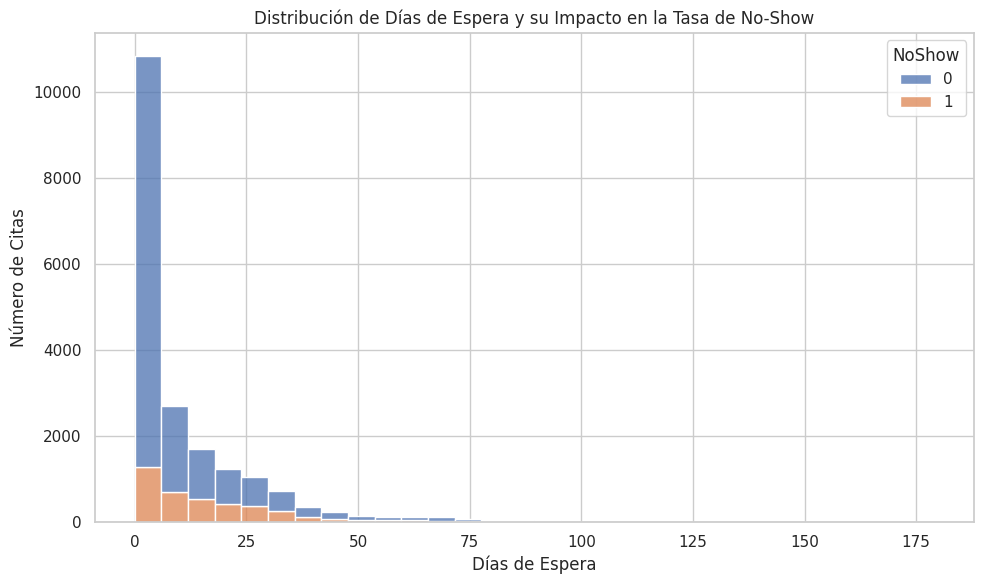

In [186]:
# Tu codigo - G1: Distribucion
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='WaitingDays', hue='NoShow', multiple='stack', bins=30)
plt.title('Distribución de Días de Espera y su Impacto en la Tasa de No-Show')
plt.xlabel('Días de Espera')
plt.ylabel('Número de Citas')
plt.tight_layout()
plt.show()

**Lectura de negocio:** Con este grafico podemos ver como se distribuye el numero de citas reservadas por los dias que tiene que esperar un cliente. aunque haya muy poca distribucion de citas con mas de 7 dias de espera la mayoria de los noshows son de citas reservadas con mas que 7 dias de espera


/tmp/ipykernel_919/3277646339.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resumen_waiting.index, y='mean', data=resumen_waiting, palette='magma')


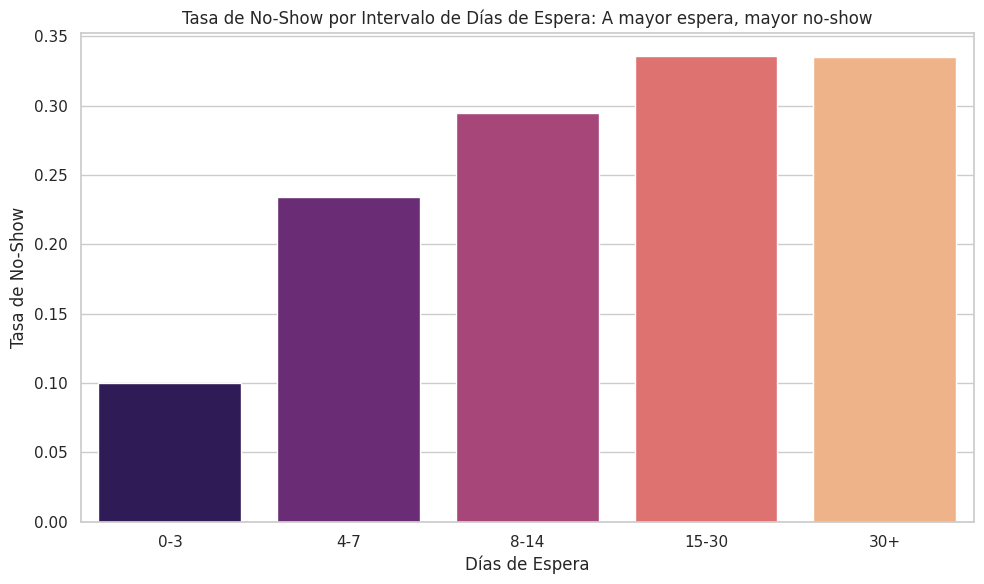

In [187]:
# Tu codigo - G2: Comparacion

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=resumen_waiting.index, y='mean', data=resumen_waiting, palette='magma')
plt.title('Tasa de No-Show por Intervalo de Días de Espera: A mayor espera, mayor no-show')
plt.xlabel('Días de Espera')
plt.ylabel('Tasa de No-Show')
plt.tight_layout()
plt.show()

**Lectura de negocio:** En este grafico se puede ver que la mayor sea los dias de espera, mayor la tasa de noshow

/tmp/ipykernel_919/3145853324.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_age_waiting = df_clean.groupby(['AgeGroup', 'WaitingBin'])['NoShow'].mean().unstack()


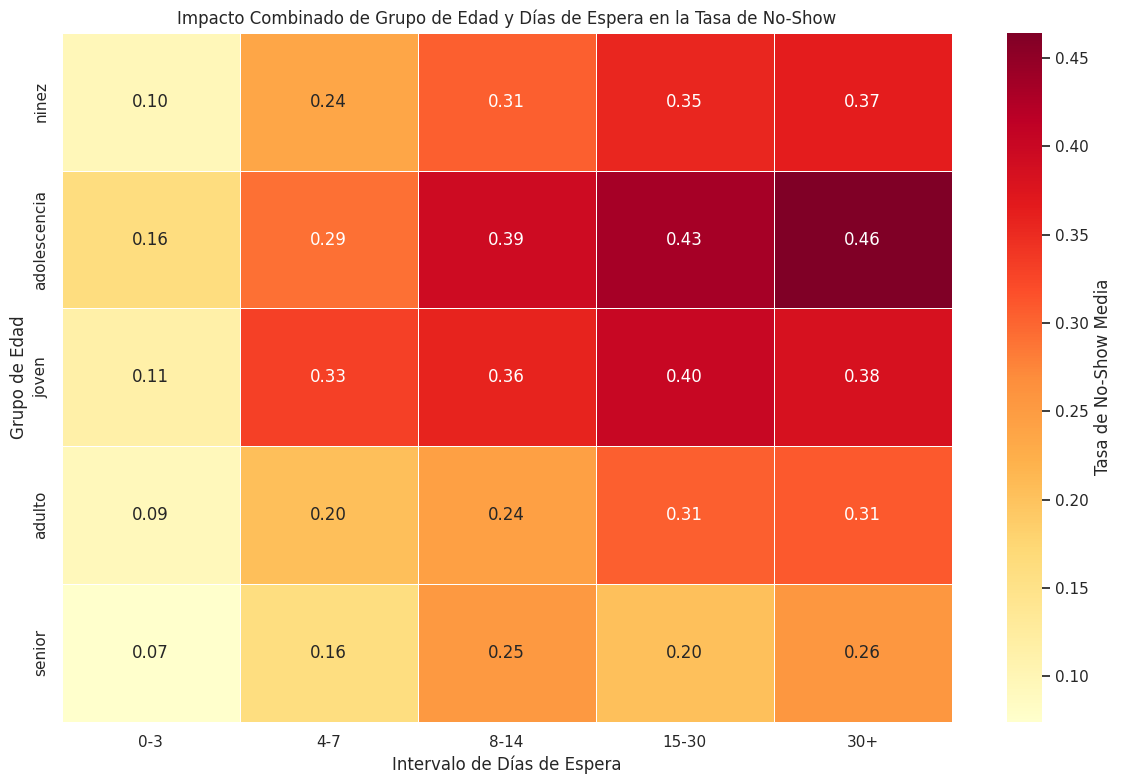

In [188]:
# Tu codigo - G3: Relacion (heatmap)

import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table for the heatmap
# The 'NoShow' column already contains 0 for No and 1 for Yes, so the mean directly gives the no-show rate.
resumen_age_waiting = df_clean.groupby(['AgeGroup', 'WaitingBin'])['NoShow'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(resumen_age_waiting, annot=True, fmt=".2f", cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Tasa de No-Show Media'})
plt.title('Impacto Combinado de Grupo de Edad y Días de Espera en la Tasa de No-Show')
plt.xlabel('Intervalo de Días de Espera')
plt.ylabel('Grupo de Edad')
plt.tight_layout()
plt.show()

**Lectura de negocio:** En este grafico heatmap nos ensena la que los adolescentes con mas de 14 dias de espera son los que mas probabilidad tienen de faltar una cita

/tmp/ipykernel_919/298063778.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_highest_filtered.index, y='mean', data=top_10_highest_filtered, palette='Reds_d')


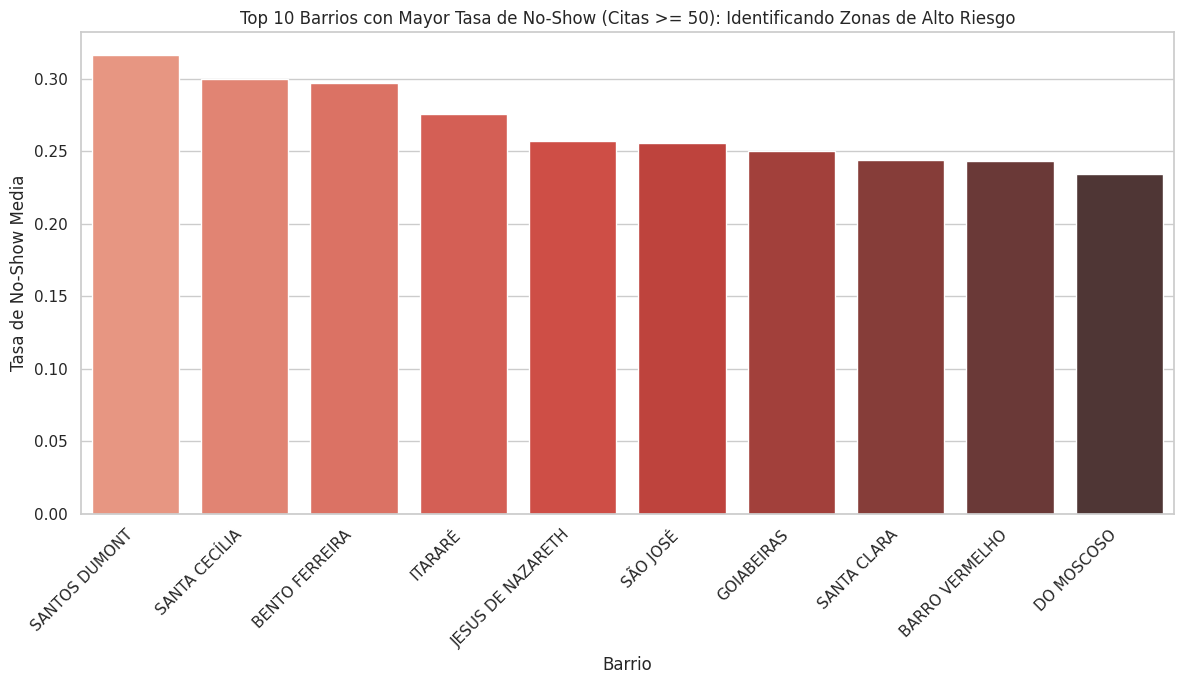

In [189]:
# Tu codigo - G4: Comparacion de barrios (filtra n >= 50)

import matplotlib.pyplot as plt
import seaborn as sns

# Filter neighbourhoods with count >= 50 (re-using the logic from previous cells)
significant_neighbourhoods = resumen_neighbourhood[resumen_neighbourhood['count'] >= 50]

# Get top 10 highest no-show rates among significant neighbourhoods
top_10_highest_filtered = significant_neighbourhoods.sort_values(by='mean', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_highest_filtered.index, y='mean', data=top_10_highest_filtered, palette='Reds_d')
plt.title('Top 10 Barrios con Mayor Tasa de No-Show (Citas >= 50): Identificando Zonas de Alto Riesgo')
plt.xlabel('Barrio')
plt.ylabel('Tasa de No-Show Media')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Lectura de negocio:** Este grafico nos ensena los 10 barrios con tasa de no shows mas altos

**Lectura:** escribe **una frase de negocio por grafico** (la que dirias ensenandolo a un responsable del hospital).


# 5.- Project Canvas (cierre)

> La sintesis de negocio de **todo** tu analisis, en un solo lugar. Es lo que defenderias ante un responsable del hospital **sin ensenar codigo**. Reune aqui, con cifras de tu notebook, lo que trabajaste en las secciones 0-4.
>
> Reglas: frases cortas; numeros de tu notebook (no intuiciones); si algo no se sabe, escribelo como limite.

In [190]:
df_clean.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No-show',
       'NoShow', 'WaitingDays', 'AppointmentWeekday', 'AgeGroup',
       'WaitingBin'],
      dtype='object')

## 5.1.- Casillas 1-4

**Casilla 1 - Problema** (1-2 frases)

_La clinica se presenta con un problema de alta tasa de paciente que no acuden a la cita. Para la clinica cada cita perdida es tambien tiempo perdido para los doctores y una posible solucion para reservar ese bloque de tiempo a alguien que quieren acudir a la cita mas antes_

**Casilla 2 - KPI**

- **KPI principal:* No-Show*
- **Tipo (lagging / leading):* Leading : SMS_Received, waiting days (recuerda distinguir lagging vs leading; el baseline de no-show lo confirmaras en la seccion 1) *
- **Baseline (cifra de tu notebook):*20.2%*
- **Palanca leading candidata:* SMS_Recieved, Waiting Days, Neighbourhoods, agegroup*

**Casilla 3 - Datos disponibles**

- **Unidad de observacion (grano):*cada fila representa una cita*
- **Filas brutas / validas (tras limpiar):*19427*
- **Variables derivadas creadas:*'NoShow - binary', 'WaitingDays', 'AppointmentWeekday', 'AgeGroup', 'WaitingBin'*
- **Dato que falta y pedirias al negocio:*Distancia entre clinica y barrio*

**Casilla 4 - Riesgos DAMA-5** (los de la seccion 1.2)

- **Completitud:*600 Nulos encontrados*
- **Validez:*Age tiene dtype float (lo cual no se se suele usar y puede confundir), Age tiene valores negativos y esto es imposible, hipertension y handcap estan mal escritos, hay alguien con edad mas que 100 lo cual tambien es una anomalia,dtype de scheduled date y appointment date es object y se deberia cambiar dtype, estandardizar columnas gender y neighbournhood para eliminar espacios innecesarios y letras en mayusculas y minisculas inconsistentes, eliminar la fila con valor imposible -1  de waiting day encontrado despues de normalizar la columnas*
- **Consistencia:*En este caso la columna no show tiene un falso negativo que es una consitencia y puede affectar nuestra hipotesis final *
- **Unicidad / grano:*hay 50 filas duplicados*

## 5.2.- Casilla 5 - Hipotesis PECO (cada una con su grafico)

Para cada una escribe P / E / C / O, la evidencia (tasa + denominador) y el grafico que la ilustra.

### H1
- **P / E / C / O:**
  - **P:** Pacientes de la clínica.
  - **E:** Pacientes con mayor tiempo de espera.
  - **C:** Pacientes con menor tiempo de espera.
  - **O:** Mayor tasa de No-Show.

- **Evidencia (tasa + denominador):**

| WaitingBin | Tasa No-Show | n |
|------------|-------------|------|
| 0-3 días | 9.99% | 9.288 |
| 4-7 días | 23.44% | 3.118 |
| 8-14 días | 29.50% | 2.159 |
| 15-30 días | 33.58% | 3.064 |
| 30+ días | 33.54% | 1.798 |

La tasa de No-Show aumenta progresivamente conforme crecen los días de espera.

- **Grafico:**
  - **G2 – Comparación:** "Tasa de No-Show por Intervalo de Días de Espera: A mayor espera, mayor no-show".

---

### H2
- **P / E / C / O:**
  - **P:** Pacientes de la clínica.
  - **E:** Adolescentes y jóvenes.
  - **C:** Niñez, adultos y seniors.
  - **O:** Mayor tasa de No-Show.

- **Evidencia:**

| AgeGroup | Tasa No-Show | n |
|-----------|-------------|------|
| Adolescencia | 27.36% | 1.122 |
| Joven | 25.16% | 4.448 |
| Niñez | 20.57% | 3.642 |
| Adulto | 18.15% | 7.598 |
| Senior | 14.29% | 2.617 |

Los grupos de adolescencia y juventud presentan las tasas más elevadas de ausencias.

- **Grafico:**
  - **G3 – Relación (Heatmap):** "Impacto Combinado de Grupo de Edad y Días de Espera en la Tasa de No-Show".

---

### H3
- **P / E / C / O:**
  - **P:** Pacientes de la clínica.
  - **E:** Pacientes residentes en determinados barrios.
  - **C:** Pacientes de otros barrios o promedio de la clínica.
  - **O:** Mayor o menor tasa de No-Show.

- **Evidencia:**

Barrios con al menos 50 citas:

| Barrio | Tasa No-Show | n |
|----------|-------------|------|
| SANTOS DUMONT | 31.62% | 234 |
| SANTA CECÍLIA | 30.00% | 80 |
| BENTO FERREIRA | 29.71% | 175 |
| ITARARÉ | 27.60% | 616 |
| JESUS DE NAZARETH | 25.71% | 490 |

Existen diferencias relevantes entre barrios, lo que sugiere factores geográficos o socioeconómicos asociados al No-Show.

- **Grafico:**
  - **G4 – Comparación de barrios:** "Top 10 Barrios con Mayor Tasa de No-Show (Citas ≥ 50)".

---

### H4 (tu hipotesis propia)
- **P / E / C / O:**
  - **P:** Pacientes de la clínica.
  - **E:** Pacientes con Scholarship.
  - **C:** Pacientes sin Scholarship.
  - **O:** Mayor tasa de No-Show, especialmente cuando existen factores de riesgo adicionales.

- **Evidencia:**

| Scholarship | SMS | Tasa No-Show | n |
|--------------|-----|-------------|------|
| No | No | 15.07% | 5.045 |
| No | Sí | 25.59% | 2.553 |
| Sí | No | 24.51% | 714 |
| Sí | Sí | 32.05% | 408 |

Los pacientes con Scholarship muestran tasas de No-Show superiores en todos los escenarios observados.

- **Grafico:**
  - **G3 – Heatmap (relación entre factores)**, complementado por el análisis de tablas cruzadas Scholarship × SMS.

---

### Limite de interpretacion comun:

Todas las hipótesis muestran asociaciones observadas en los datos, pero no permiten demostrar causalidad. Una tasa más alta no implica que el factor analizado sea la causa directa del No-Show. Además, siempre debe considerarse el denominador (número de citas) para evitar interpretar como relevantes diferencias observadas en grupos pequeños. Variables como SMS, barrio o Scholarship pueden estar influenciadas por otros factores no observados en el dataset.

## 5.3.- Casilla 6 - Decision candidata + limites

### Decision:
Implementar una estrategia de reducción de No-Show enfocada primero en:

1. Pacientes con tiempos de espera largos (más de 7 días).
2. Pacientes jóvenes y adolescentes.
3. Barrios con tasas históricamente altas de No-Show.

Estas intervenciones pueden incluir recordatorios adicionales, confirmación activa de asistencia o reasignación prioritaria de citas.

### Graficos que la respaldan:
- **G2:** Tasa de No-Show por Intervalo de Días de Espera.
- **G3:** Heatmap Edad × Días de Espera.
- **G4:** Top 10 Barrios con Mayor Tasa de No-Show.

### Limites (que NO puedes concluir todavia):
- No se puede afirmar que una mayor espera cause directamente el No-Show.
- No se puede concluir que la edad sea la razón de la ausencia; puede estar asociada a otros factores no medidos.
- No se puede afirmar que vivir en un barrio específico provoque el No-Show.
- No se puede asegurar que una intervención reducirá el No-Show sin realizar una prueba o evaluación posterior.
- El análisis es observacional y muestra asociaciones, no relaciones causales.

---

## Frases para el stakeholder

### 1.
**Decisión:** Priorizar acciones sobre pacientes con esperas largas.

**Gráfico:** G2 – Tasa de No-Show por Intervalo de Días de Espera.

**Frase sin jerga técnica:**
"Cuanto más tiempo espera un paciente para su cita, más probable es que no asista; por eso conviene reducir las esperas o reforzar los recordatorios."

### 2.
**Decisión:** Dirigir campañas de recordatorio a jóvenes y adolescentes.

**Gráfico:** G3 – Heatmap Edad × Días de Espera.

**Frase sin jerga técnica:**
"Los pacientes más jóvenes faltan con mayor frecuencia, especialmente cuando deben esperar varios días para ser atendidos."

### 3.
**Decisión:** Concentrar esfuerzos en los barrios con mayores tasas de ausencia.

**Gráfico:** G4 – Top 10 Barrios con Mayor Tasa de No-Show.

**Frase sin jerga técnica:**
"Algunos barrios presentan sistemáticamente más ausencias que otros, por lo que enfocar allí las acciones puede generar un mayor impacto."

# 6.- Reflexion metacognitiva

## 6.1.- Conceptos que necesito repasar

Lista los conceptos o metodos que se te atascaron: que intentabas hacer, donde buscaste ayuda y que prioridad de repaso le das (alta / media / baja).

- aprender crear variables significativos que me van a ayudar con el analyisis y la evaluacion
- aprender crear funciones para mas fluidez y rapidez en mi trabajo
- aprender como derivar una conclusion profundo o una solucion significativa

## 6.2.- Autoevaluacion

- **Que parte del analisis te resulto mas facil? Por que?
*Me resultó muy facil aprender como limpiar los datos*
- **Que parte te resulto mas dificil? Por que?
*Respuesta:Me resultó muy dificil entender como crear y prepara variables que me pueden ayudar o rechazar mi hipotesis y crear hipotesis de ante mano*
- **Que aprendiste que no sabias antes de empezar?
*Respuesta:aprendi muchas funciones de Pandasy aprendi como utilizar este formato o metodologia para hacer un analisis de datos*
- **Si tuvieras que repetir el analisis, que harias diferente?
*Respuesta:Intentaría entender si puede haber mas correlaciones que podria buscar entre los datos*
- **Cuanto tiempo te tomo completar este notebook?
*Respuesta:2 dias*

# Checklist final y entrega

- [x] El notebook se ejecuta de principio a fin sin errores (*Entorno de ejecucion -> Reiniciar y ejecutar todo*).
- [x] Cada seccion tiene **codigo + lectura de negocio** (no solo outputs).
- [x] Las **4 familias visuales** estan, con **titulo = frase de negocio** y ejes etiquetados.
- [x] El **Project Canvas (seccion 5)** esta completo y es coherente con tu analisis.
- [x] **H4** (tu hipotesis propia, seccion 3.4) esta planteada y comprobada.
- [x] La **reflexion metacognitiva (seccion 6)** esta completa y es honesta.
- [x] Entregas **un unico archivo**: `EDA_NoShow_[TU_APELLIDO].ipynb`.

**Entrega en el Aula Virtual antes del domingo 31/05/2026, 23:45h.**  Exito!

# Recursos y cheatsheets

Si te atascas o necesitas recordar sintaxis, estos recursos ayudan.

## Python basico

| Recurso | Para que | Link |
|---|---|---|
| Python Cheatsheet | sintaxis basica: tipos, bucles, funciones, slicing | https://pythoncheatsheet.org/ |
| Real Python Cheat Sheet | resumen compacto de tipos, colecciones y control de flujo | https://realpython.com/files/Python3CheatSheet.pdf |

## Pandas (manipulacion de datos)

| Recurso | Para que | Link |
|---|---|---|
| Pandas Cheat Sheet (oficial) | seleccion, filtrado, groupby, pivot | https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf |

**Operaciones mas usadas en esta actividad:**
```python
# exploracion
df.shape, df.head(), df.info(), df.describe()

# calidad de datos (DAMA-5)
df.isna().sum(); df.duplicated().sum(); df["col"].value_counts()

# limpieza
df["col"].str.strip().str.upper(); df.drop_duplicates(); df.dropna(subset=["col"])

# fechas y variables derivadas
pd.to_datetime(df["col"]).dt.normalize()
pd.cut(df["Age"], bins=[-1, 12, 17, 35, 64, 200], labels=[...])

# evidencia por grupo: tasa + denominador SIEMPRE juntos
df.groupby("col")["NoShow"].agg(["mean", "size"])
```

## Visualizacion (matplotlib + seaborn)

| Recurso | Para que | Link |
|---|---|---|
| Python Graph Gallery | ejemplos y arbol de decision para elegir grafico | https://python-graph-gallery.com/ |
| Seaborn Cheat Sheet (DataCamp) | flujo completo con seaborn | https://www.datacamp.com/cheat-sheet/python-seaborn-cheat-sheet |
| Matplotlib Cheat Sheet (Dataquest) | plot, scatter, bar, hist, subplots | https://www.dataquest.io/cheat-sheet/matplotlib-cheat-sheet/ |

**Que grafico usar (las 4 familias):**

| Familia | Pregunta | Ejemplo |
|---|---|---|
| Distribucion | como se reparte una variable? | `sns.histplot(df["WaitingDays"])` |
| Comparacion | difiere la tasa entre grupos? | `sns.barplot(x="WaitingBin", y="NoShow", data=resumen)` |
| Relacion | como se relacionan dos variables? | `sns.heatmap(tabla, annot=True)` |
| Composicion | partes de un todo | barras apiladas / countplot |

**Buenas practicas en cada grafico:**
```python
plt.figure(figsize=(10, 6))
# ... tu grafico ...
plt.title("Titulo = frase de negocio")   # no "Grafico 1"
plt.xlabel("..."); plt.ylabel("...")
plt.tight_layout(); plt.show()
```

## Tips finales

1. **Documentacion oficial:** `df.groupby?` en una celda muestra la ayuda.
2. **Busca el error:** copia el mensaje en Google / Stack Overflow.
3. **IA con criterio:** pidele que explique, no que decida por ti (dale los nombres reales de las columnas).
4. **Prueba y error:** ejecuta y lee el resultado antes de avanzar.